# Rheology Pipeline Run: dynamic_analysis_full_run_custom_20260513_093259

This notebook runs rheology prediction and cell-level prediction-accuracy analysis for one raw dataset.

Dataset: dynamic_analysis_full_run_custom_20260513_093259.csv
Calibration: {'h_c': 0.23239941856115517, 'k': 5.759664583228962e-09, 'p': 1.9837009932757987, 'R2_calibration': 0.9887274748058604, 'n_silicones': 23}


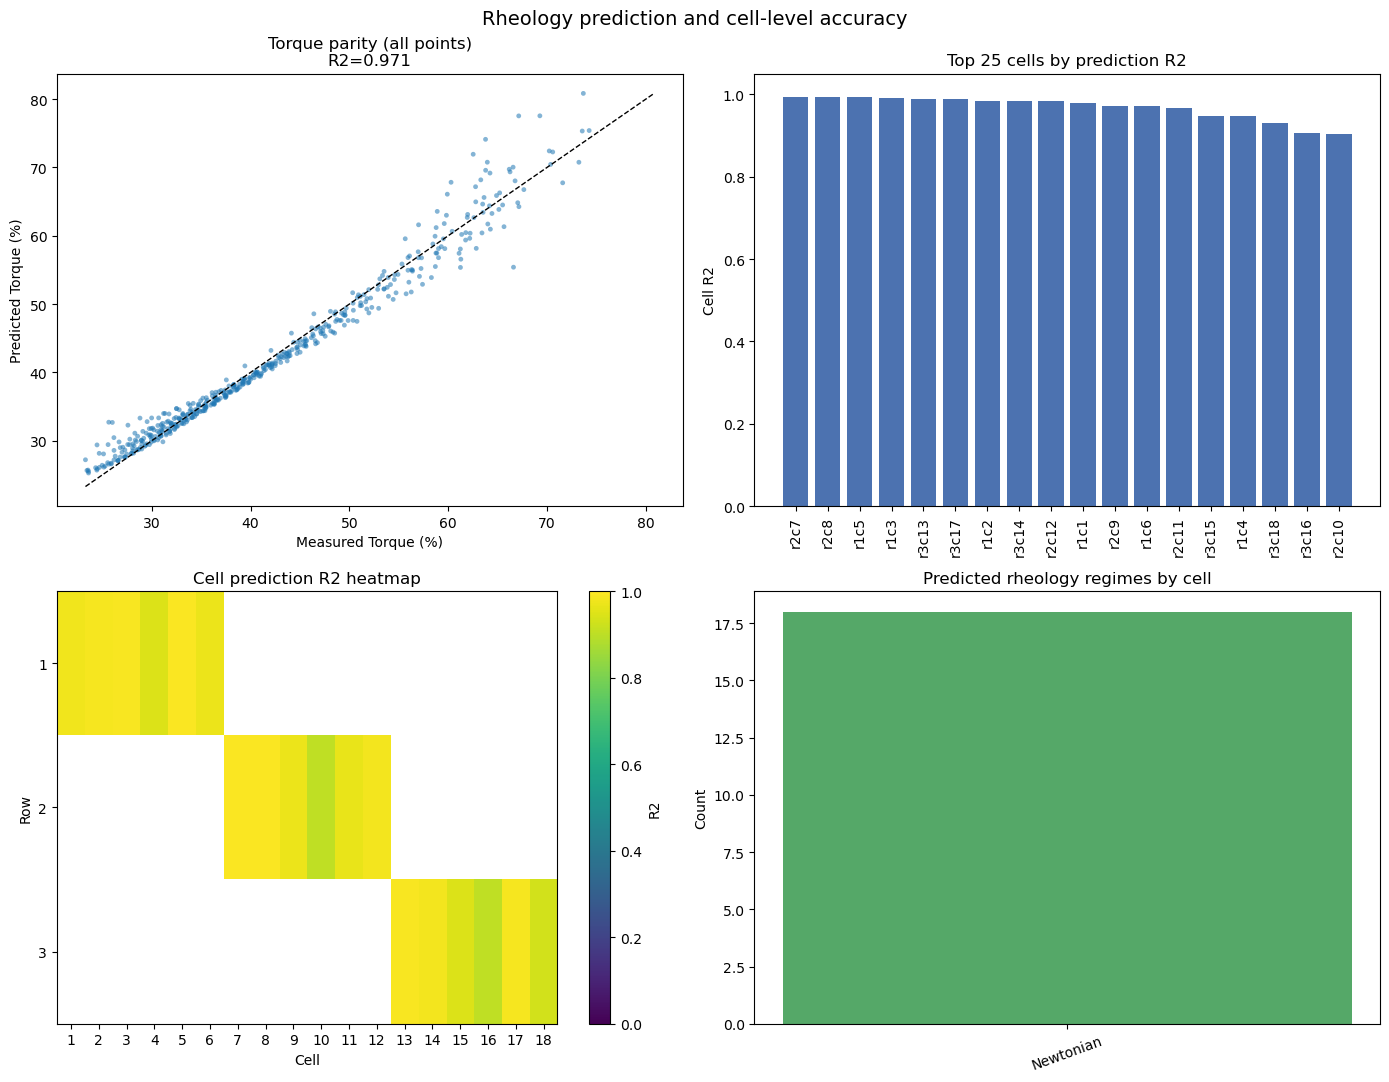

Cells analyzed: 18
Median cell R2: 0.981
Median cell MAPE (%): 2.806


,row,cell,Cell_Label,fluid_id,n_rpms,regime,n_flow,K_Pas_n,cell_R2,cell_RMSE_Tpct,cell_MAE_Tpct,cell_MAPE_pct
0,1,1,l1000_b_a_,r1_c1|l1000_b_a_,1,Newtonian,1.0,8.523181,0.979335,1.923020,1.263470,2.751433
1,1,2,l1000_sl_a1154,r1_c2|l1000_sl_a1154,1,Newtonian,1.0,8.641452,0.984425,1.703976,1.182691,2.497387
2,1,3,l2000_sdl_a3347,r1_c3|l2000_sdl_a3347,1,Newtonian,1.0,13.219469,0.990200,1.092572,0.790488,2.095372
3,1,4,l4000_sdl_a6611,r1_c4|l4000_sdl_a6611,1,Newtonian,1.0,17.840703,0.946201,2.519487,2.028215,4.914167
4,1,5,l5000_b_a5856,r1_c5|l5000_b_a5856,1,Newtonian,1.0,16.773703,0.993597,0.829820,0.683569,2.026755
5,1,6,l8000_sdl_a8930,r1_c6|l8000_sdl_a8930,1,Newtonian,1.0,21.448961,0.970546,1.836451,1.427136,3.666188
6,2,7,l10000_sl_a11860,r2_c7|l10000_sl_a11860,1,Newtonian,1.0,26.338255,0.994387,0.906877,0.669873,1.784883
7,2,8,l12500_b_14590,r2_c8|l12500_b_14590,1,Newtonian,1.0,27.104665,0.994373,0.906353,0.760632,1.829899
8,2,9,l15000_sdl_a19000,r2_c9|l15000_sdl_a19000,1,Newtonian,1.0,33.896834,0.971046,1.993090,1.453386,3.600210
9,2,10,l25000_sdl_a22730,r2_c10|l25000_sdl_a22730,1,Newtonian,1.0,36.838886,0.903835,3.833813,3.028009,6.583163


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from rheology_pipeline_core import RheologyPipeline, fit_drag_profile

DATASET_PATH = Path(r"c:/Users/mrast/OneDrive/Documents/GitHub/Automated_Viscometry/results/Auto-runs/dynamic_analysis_full_run_custom_20260513_093259.csv")
CALIBRATION_PATH = DATASET_PATH.parent / "height_normalized.csv"
OUT_DIR = DATASET_PATH.parent / "outputs_pipeline" / "dynamic_analysis_full_run_custom_20260513_093259"
FIG_DIR = DATASET_PATH.parent / "figures_pipeline" / "dynamic_analysis_full_run_custom_20260513_093259"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATASET_PATH.name)

df = pd.read_csv(DATASET_PATH)
df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")].copy()

for c in ["row", "cell", "Z_Height_mm", "RPM", "Rotational_Drag", "Torque_%"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

if "Torque_%" in df.columns and df["Torque_%"].notna().any():
    df["T_pct"] = df["Torque_%"]
else:
    df["T_pct"] = df["Rotational_Drag"] * df["RPM"]

if "Rotational_Drag" not in df.columns or df["Rotational_Drag"].isna().all():
    df["Rotational_Drag"] = df["T_pct"] / df["RPM"]

df = df.dropna(subset=["row", "cell", "Cell_Label", "Z_Height_mm", "RPM", "T_pct"]).copy()
df["row"] = df["row"].astype(int)
df["cell"] = df["cell"].astype(int)
df["Cell_Label"] = df["Cell_Label"].astype(str)

df["fluid_id"] = df.apply(lambda r: f"r{r['row']}_c{r['cell']}|{r['Cell_Label']}", axis=1)
df["h_mm"] = df.groupby(["row", "cell", "RPM"])["Z_Height_mm"].transform(lambda s: s - s.min())
df["D"] = df["T_pct"] / df["RPM"]

pipeline = RheologyPipeline()
if CALIBRATION_PATH.exists():
    cal = pipeline.load_silicone_calibration(CALIBRATION_PATH)
    print("Calibration:", cal)
else:
    pipeline.set_calibration(h_c=0.2534, k=3.45e-4, p=1.026)
HC = pipeline.H_C_UNIVERSAL

MIN_PTS = 6
sweep_rows, pred_rows = [], []

for (row, cell, label, fid, rpm), g in df.groupby(["row", "cell", "Cell_Label", "fluid_id", "RPM"], dropna=False):
    g = g.sort_values("h_mm")
    if len(g) < MIN_PTS:
        continue
    fit = fit_drag_profile(g["h_mm"].values, g["D"].values, h_c=HC)
    if not np.isfinite(fit["A"]):
        continue

    D_pred = fit["A"] / (g["h_mm"].values + HC) + fit["B"]
    T_pred = D_pred * rpm
    T_true = g["T_pct"].values

    err = T_pred - T_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    mape = float(np.mean(np.abs(err) / np.maximum(np.abs(T_true), 1e-9)) * 100.0)
    ss_res = float(np.sum((T_true - T_pred) ** 2))
    ss_tot = float(np.sum((T_true - np.mean(T_true)) ** 2))
    r2_pred = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    sweep_rows.append({
        "row": row, "cell": cell, "Cell_Label": label, "fluid_id": fid, "rpm": rpm,
        "n_pts": len(g), "A": fit["A"], "B": fit["B"], "fit_R2_D": fit["R2"],
        "pred_R2_T": r2_pred, "MAE_Tpct": mae, "RMSE_Tpct": rmse, "MAPE_pct": mape
    })

    tmp = g[["row", "cell", "Cell_Label", "fluid_id", "RPM", "h_mm", "T_pct"]].copy()
    tmp["T_pred_pct"] = T_pred
    tmp["abs_err"] = np.abs(tmp["T_pred_pct"] - tmp["T_pct"])
    tmp["ape_pct"] = tmp["abs_err"] / np.maximum(np.abs(tmp["T_pct"]), 1e-9) * 100.0
    pred_rows.append(tmp)

sweeps = pd.DataFrame(sweep_rows)
pred_points = pd.concat(pred_rows, ignore_index=True) if pred_rows else pd.DataFrame()

cell_rows = []
for (row, cell, label, fid), gcell in df.groupby(["row", "cell", "Cell_Label", "fluid_id"], dropna=False):
    sweeps_cell = sweeps[(sweeps["row"] == row) & (sweeps["cell"] == cell)]
    if sweeps_cell.empty:
        continue

    rpm_values = sorted(sweeps_cell["rpm"].unique().tolist())
    h_list, t_list = [], []
    for rpm in rpm_values:
        gg = gcell[np.isclose(gcell["RPM"], rpm, atol=0.05)].sort_values("h_mm")
        if len(gg) >= MIN_PTS:
            h_list.append(gg["h_mm"].values)
            t_list.append(gg["T_pct"].values)

    if len(h_list) == 0:
        continue

    if len(h_list) == 1:
        rheo = pipeline.predict_rheology(h_list[0], t_list[0], rpm_values[0])
    else:
        rheo = pipeline.predict_rheology(h_list, t_list, rpm_values)

    pp = pred_points[(pred_points["row"] == row) & (pred_points["cell"] == cell)]
    if len(pp):
        y_true = pp["T_pct"].values
        y_pred = pp["T_pred_pct"].values
        err = y_pred - y_true
        mae = float(np.mean(np.abs(err)))
        rmse = float(np.sqrt(np.mean(err**2)))
        mape = float(np.mean(np.abs(err) / np.maximum(np.abs(y_true), 1e-9)) * 100.0)
        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    else:
        mae = rmse = mape = r2 = np.nan

    cell_rows.append({
        "row": row, "cell": cell, "Cell_Label": label, "fluid_id": fid,
        "n_rpms": len(h_list), "regime": rheo.get("regime", "unknown"),
        "n_flow": rheo.get("n", np.nan), "K_Pas_n": rheo.get("K_Pas_n", np.nan),
        "cell_R2": r2, "cell_RMSE_Tpct": rmse, "cell_MAE_Tpct": mae, "cell_MAPE_pct": mape
    })

cells = pd.DataFrame(cell_rows).sort_values(["row", "cell"]).reset_index(drop=True)

sweeps.to_csv(OUT_DIR / "sweep_fits.csv", index=False)
pred_points.to_csv(OUT_DIR / "point_predictions.csv", index=False)
cells.to_csv(OUT_DIR / "cell_rheology_accuracy.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

ax = axes[0, 0]
if len(pred_points):
    x = pred_points["T_pct"].values
    y = pred_points["T_pred_pct"].values
    ax.scatter(x, y, s=12, alpha=0.55, edgecolors="none")
    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ss_res = float(np.sum((x - y) ** 2))
    ss_tot = float(np.sum((x - np.mean(x)) ** 2))
    r2_all = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    ax.set_title(f"Torque parity (all points)\nR2={r2_all:.3f}")
ax.set_xlabel("Measured Torque (%)")
ax.set_ylabel("Predicted Torque (%)")

ax = axes[0, 1]
if len(cells):
    top = cells.sort_values("cell_R2", ascending=False).head(25).copy()
    top["cell_id"] = top.apply(lambda r: f"r{int(r['row'])}c{int(r['cell'])}", axis=1)
    ax.bar(top["cell_id"], top["cell_R2"], color="#4C72B0")
    ax.set_ylim(0, 1.05)
    ax.set_title("Top 25 cells by prediction R2")
    ax.tick_params(axis="x", labelrotation=90)
ax.set_ylabel("Cell R2")

ax = axes[1, 0]
if len(cells):
    heat = cells.pivot_table(index="row", columns="cell", values="cell_R2", aggfunc="mean")
    im = ax.imshow(heat.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_title("Cell prediction R2 heatmap")
    ax.set_xlabel("Cell")
    ax.set_ylabel("Row")
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels(heat.columns.astype(int))
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels(heat.index.astype(int))
    fig.colorbar(im, ax=ax, label="R2")

ax = axes[1, 1]
if len(cells):
    reg = cells["regime"].value_counts()
    ax.bar(reg.index.astype(str), reg.values, color="#55A868")
    ax.set_title("Predicted rheology regimes by cell")
    ax.tick_params(axis="x", rotation=20)
ax.set_ylabel("Count")

fig.suptitle("Rheology prediction and cell-level accuracy", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "prediction_accuracy_dashboard.png", dpi=220, bbox_inches="tight")
plt.show()

print("Cells analyzed:", len(cells))
print("Median cell R2:", round(float(cells["cell_R2"].median()), 4) if len(cells) else np.nan)
print("Median cell MAPE (%):", round(float(cells["cell_MAPE_pct"].median()), 3) if len(cells) else np.nan)
cells.head(20)